In [1]:
# STANDIN A0
%run 00_setup.ipynb

Python 3.13.7, scikit-learn 1.6.1, numpy 2.5.3, pandas 3.0.6
Working directory: /home/steven/Desktop/AI-For-Cybersecurity-Lab-4.2-Robustness-attacks


train 267,984 rows   attack rate 0.1507
val    89,328 rows   attack rate 0.1507
test   89,329 rows   attack rate 0.1507


68 features: 58 continuous, 10 flag columns
Flag columns: Fwd PSH Flags, Fwd URG Flags, FIN Flag Count, SYN Flag Count, RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count, ECE Flag Count
  tree    loaded from models/tree.joblib
  logreg  loaded from models/logreg.joblib


  forest  loaded from models/forest.joblib


ATTACK_IDX: 50 detected attacks, forest probability 1.000-1.000
  attack types: {'DDoS': 25, 'DoS Hulk': 22, 'DoS GoldenEye': 2, 'SSH-Patator': 1}
EXPLAIN_IDX: 500 random test flows, 68 of them attacks
Setup complete: 20 shared names ready. The models are scored in step A2.


<!-- STEP A1 -->
## Part A: The baseline

### Step A1: Check the data is healthy

Infinite or missing values would make the noise (Part B) and the attack (Part C) crash or produce
nonsense, so we check for them before anything else. We also count which columns are continuous and
which are 0/1 flags, because Part B adds noise to continuous columns only.

In [2]:
# STEP A1
print(f"X_train {X_train.shape}, X_val {X_val.shape}, X_test {X_test.shape}")
print(f"Share of attacks in the training labels: {y_train.mean():.4f}")

# np.isfinite is False for +inf, -inf and NaN, so one check covers infinities and missing values.
finite = {name: bool(np.isfinite(part).all().all())
          for name, part in (("train", X_train), ("val", X_val), ("test", X_test))}
print("All values finite:", finite)

if not all(finite.values()):
    # Not needed for our data (Lab 1 dropped every row with an infinity or NaN), but this is the fix:
    # turn infinities into NaN, then fill with the TRAINING median, never a test-set statistic.
    for part in (X_train, X_val, X_test):
        part.replace([np.inf, -np.inf], np.nan, inplace=True)
        part.fillna(TRAIN_MEDIAN, inplace=True)
assert all(np.isfinite(part).all().all() for part in (X_train, X_val, X_test))

print(f"\n{len(CONT_COLS)} continuous columns (more than two distinct values in training), "
      f"{len(FLAG_COLS)} flag columns:")
print("  " + ", ".join(FLAG_COLS))

X_train (267984, 68), X_val (89328, 68), X_test (89329, 68)
Share of attacks in the training labels: 0.1507


All values finite: {'train': True, 'val': True, 'test': True}



58 continuous columns (more than two distinct values in training), 10 flag columns:
  Fwd PSH Flags, Fwd URG Flags, FIN Flag Count, SYN Flag Count, RST Flag Count, PSH Flag Count, ACK Flag Count, URG Flag Count, CWE Flag Count, ECE Flag Count


In [3]:
# STEP A1
# Two things the later steps need to know about the continuous columns: are some values negative
# (matters for clipping noise at zero in B1), and how heavy-tailed are they (a few enormous values).
q = X_train[CONT_COLS].quantile([0.5, 0.99])
health = pd.DataFrame({
    "min": X_train[CONT_COLS].min(),
    "median": q.loc[0.5],
    "p99": q.loc[0.99],
    "max": X_train[CONT_COLS].max(),
    "max_over_p99": X_train[CONT_COLS].max() / q.loc[0.99].replace(0, np.nan),
})
negative = health.index[health["min"] < 0].tolist()
print(f"{len(negative)} continuous columns contain negative values in training:")
print("  " + ", ".join(negative))
print("\nMost heavy-tailed columns (maximum compared with the 99th percentile):")
print(health.sort_values("max_over_p99", ascending=False).head(5)[["median", "p99", "max"]]
      .to_string(float_format=lambda v: f"{v:,.0f}"))

summary = pd.DataFrame([{
    "train_rows": len(X_train), "val_rows": len(X_val), "test_rows": len(X_test),
    "features": len(FEATURES), "continuous": len(CONT_COLS), "flags": len(FLAG_COLS),
    "attack_rate_train": round(y_train.mean(), 4), "attack_rate_test": round(y_test.mean(), 4),
    "all_finite": all(finite.values()), "columns_with_negatives": len(negative),
}])
summary.to_csv("results/tables/A1_data_health.csv", index=False)
summary.T.rename(columns={0: "value"})

11 continuous columns contain negative values in training:
  Flow Duration, Flow Bytes/s, Flow Packets/s, Flow IAT Mean, Flow IAT Max, Flow IAT Min, Fwd Header Length, Bwd Header Length, Init_Win_bytes_forward, Init_Win_bytes_backward, min_seg_size_forward

Most heavy-tailed columns (maximum compared with the 99th percentile):
                             median    p99         max
Subflow Bwd Bytes               190 91,561 593,469,129
Total Length of Bwd Packets     190 91,561 593,000,000
act_data_pkt_fwd                  1     32     192,326
Subflow Bwd Packets               2     69     272,353
Total Backward Packets            2     69     272,353


,value
train_rows,267984
val_rows,89328
test_rows,89329
features,68
continuous,58
flags,10
attack_rate_train,0.1507
attack_rate_test,0.1507
all_finite,True
columns_with_negatives,11


<!-- STEP A1 -->
**What we found.** About 15% of the flows are attacks in every part of the split. Every value is
finite: Lab 1 already dropped the rows where `Flow Bytes/s` or `Flow Packets/s` were infinite (a
division by a zero duration), so nothing had to be fixed here. 58 of the 68 columns are continuous and
only the 10 flag columns are 0/1. That is the opposite of the phishing data in Lab 4.1, where many
features were flags.

Two warnings for Part B. Several continuous columns contain negative values in the raw data (−1 means
"not recorded", and the header lengths have a known CICFlowMeter bug), so clipping noisy values at
zero would also change real data. And the columns are heavy-tailed: the largest values are many times
the 99th percentile, so noise sized by the standard deviation will hit rows unevenly.

<!-- STEP A2 -->
### Step A2: Score the three models, and the model that does nothing

`report()` (from the setup) already includes PR-AUC, so it returns macro-F1, recall, ROC-AUC, PR-AUC
and FAR, plus accuracy for comparison. The "always benign" model is scikit-learn's
`DummyClassifier(strategy="constant", constant=0)`: it answers *benign* for every flow, so it goes
through the same `report()` as the real models. Its accuracy is `1 - y_test.mean()` and its recall
is zero.

In [4]:
# STEP A2
from sklearn.dummy import DummyClassifier

always_benign = DummyClassifier(strategy="constant", constant=0).fit(X_train, y_train)

baseline = pd.DataFrame(
    {name: report(model, X_test, y_test)
     for name, model in [("always benign", always_benign), *MODELS.items()]}).T
baseline.index.name = "model"

# The always-benign accuracy and recall must be exactly what the lab says.
assert np.isclose(baseline.loc["always benign", "accuracy"], 1 - y_test.mean())
assert baseline.loc["always benign", "recall"] == 0

baseline.to_csv("results/tables/A2_baseline.csv", float_format="%.4f")
baseline.round(4)

,accuracy,macro_f1,recall,roc_auc,pr_auc,far
model,,,,,,
always benign,0.8493,0.4593,0.0000,0.5000,0.1507,0.0000
tree,0.9985,0.9970,0.9950,0.9971,0.9907,0.0009
logreg,0.9720,0.9416,0.8320,0.9915,0.9693,0.0032
forest,0.9984,0.9968,0.9923,0.9999,0.9998,0.0006


In [5]:
# STEP A2
# Numbers for the two "Check yourself" questions.
acc_benign = baseline.loc["always benign", "accuracy"]
acc_forest = baseline.loc["forest", "accuracy"]
print(f"Accuracy: always benign {acc_benign:.4f}, forest {acc_forest:.4f}, "
      f"margin {acc_forest - acc_benign:+.4f}")
print(f"Errors:   always benign {1 - acc_benign:.4f}, forest {1 - acc_forest:.4f} "
      f"(the forest removes {1 - (1 - acc_forest) / (1 - acc_benign):.1%} of the errors)")
print(f"Recall:   always benign 0.0000, forest {baseline.loc['forest', 'recall']:.4f}")

real = baseline.drop(index="always benign")
print("\nBetween the three real models:")
for col in ("roc_auc", "pr_auc"):
    print(f"  {col:<8} from {real[col].min():.4f} to {real[col].max():.4f}  "
          f"(spread {real[col].max() - real[col].min():.4f})")
print(f"Gap between ROC-AUC and PR-AUC per model:")
print((real["roc_auc"] - real["pr_auc"]).round(4).to_string())

Accuracy: always benign 0.8493, forest 0.9984, margin +0.1491
Errors:   always benign 0.1507, forest 0.0016 (the forest removes 98.9% of the errors)
Recall:   always benign 0.0000, forest 0.9923

Between the three real models:
  roc_auc  from 0.9915 to 0.9999  (spread 0.0084)
  pr_auc   from 0.9693 to 0.9998  (spread 0.0305)
Gap between ROC-AUC and PR-AUC per model:
model
tree      0.0064
logreg    0.0222
forest    0.0002


<!-- STEP A2 -->
**What we found.** The always-benign model is **84.9% accurate** and catches **no attack at all**
(recall 0, macro-F1 0.46, PR-AUC 0.15, which equals the attack rate). Every later number in this lab
is compared with this table.

**Check yourself 1: how far above the always-benign accuracy is the forest?** 0.9984 against 0.8493,
a margin of +0.149. That sounds like "15 points better", but it hides most of the story. The honest
comparisons are the errors and the recall: the forest makes 0.16% errors instead of 15.07% (it removes
about 99% of them), and it catches 99.2% of the attacks instead of none. With attacks at 15% the
imbalance is milder than the lab's 2% example, so accuracy is less misleading here, but it still
makes a model that does nothing look good.

**Check yourself 2: ROC-AUC or PR-AUC, which moved more?** PR-AUC. Across the three models ROC-AUC only
spans 0.991–1.000 (a spread of 0.008), while PR-AUC spans 0.969–1.000 (0.031, more than three times as
much). Logistic regression loses 0.022 between its ROC-AUC and its PR-AUC, the forest only 0.0002.
ROC-AUC is built from the false-positive *rate*, which is divided by the 75,868 benign test flows, so
a few hundred false alarms barely move it. PR-AUC uses *precision*, which compares those false
alarms with the 13,461 attacks, so the same false alarms cost much more. That is why the lab says to
report PR-AUC on imbalanced data.

**Side note.** The single tree has the best macro-F1 (0.9970, against 0.9968 for the forest), but the
lowest ROC-AUC of the three real models. A fully grown tree gives almost every flow a probability of
exactly 0 or 1, so it decides well but cannot rank flows by how suspicious they are. Part B will show
whether its decisions also survive messy data.

<!-- STEP B1 -->
## Part B: Break the data by accident

### Step B1: Add noise

A real sensor does not measure perfectly. `add_noise` adds a small random amount to every continuous
feature and leaves the 0/1 flags alone. For each column the noise is drawn from a normal distribution
with mean 0 and standard deviation `level × (standard deviation of that column)`.

- The standard deviation comes from the **reference set**, which we always pass as the **training set**.
  Measuring it on the test set would be leakage.
- The same seed is used at every level, so the levels differ only in the *size* of the noise, not in
  its random pattern.
- **Clipping.** Durations, counts and byte totals cannot be negative in reality, so after adding noise
  we clip at zero, but only in the columns whose training minimum is ≥ 0. Eleven columns already
  contain negative values in the real data (−1 = "not recorded", and CICFlowMeter bugs, see A1);
  clipping those at zero would change genuine measurements, not just remove impossible noise. We run
  B1 with and without clipping (extra X2) to see whether this choice matters.

In [6]:
# STEP B1
import matplotlib.pyplot as plt

# Columns that are never negative in the training data: clipping these at zero only removes
# impossible values that the noise created (a negative packet count). Columns that are already
# negative in real data (-1 = "not recorded") are left alone, so clipping never edits a real value.
NONNEG_COLS = [c for c in CONT_COLS if X_train[c].min() >= 0]


def add_noise(X, X_ref, level, seed=SEED, clip=True):
    """Noisy copy of X: Gaussian noise of width level * std(X_ref) on every continuous column.

    X_ref must be the training set (std measured there, never on the data being scored).
    The 0/1 flag columns are not touched. With clip=True, columns that are never negative in
    X_ref are clipped at zero after the noise is added.
    """
    noisy = X.copy()
    if level == 0:
        return noisy
    rng = np.random.default_rng(seed)
    std = X_ref[CONT_COLS].std().to_numpy()
    values = noisy[CONT_COLS].to_numpy(dtype=float)
    values += rng.standard_normal(values.shape) * (level * std)
    if clip:
        nonneg = np.isin(CONT_COLS, [c for c in CONT_COLS if X_ref[c].min() >= 0])
        values[:, nonneg] = np.maximum(values[:, nonneg], 0.0)
    noisy[CONT_COLS] = values
    return noisy


# Sanity checks: flags untouched, level 0 changes nothing, clipped columns never negative.
_check = add_noise(X_test.iloc[:1000], X_train, 0.5)
assert _check[FLAG_COLS].equals(X_test.iloc[:1000][FLAG_COLS])
assert add_noise(X_test.iloc[:1000], X_train, 0.0).equals(X_test.iloc[:1000])
assert (_check[NONNEG_COLS] >= 0).all().all()
print(f"{len(NONNEG_COLS)} of {len(CONT_COLS)} continuous columns are clipped at zero")

47 of 58 continuous columns are clipped at zero


In [7]:
# STEP B1
NOISE_LEVELS = [0.00, 0.05, 0.10, 0.20, 0.50]

rows = []
for clip in (True, False):
    for level in NOISE_LEVELS:
        X_noisy = add_noise(X_test, X_train, level, clip=clip)
        for name, model in MODELS.items():
            rows.append({"clip": clip, "level": level, "model": name,
                         **report(model, X_noisy, y_test)})
noise_all = pd.DataFrame(rows)
noise_all.to_csv("results/tables/B1_noise.csv", index=False, float_format="%.4f")

noise = noise_all[noise_all["clip"]]                      # the main result: with clipping
print("Macro-F1 (rows: model, columns: noise level)")
print(noise.pivot(index="model", columns="level", values="macro_f1").round(4).to_string())
print("\nRecall")
print(noise.pivot(index="model", columns="level", values="recall").round(4).to_string())

Macro-F1 (rows: model, columns: noise level)
level     0.00    0.05    0.10    0.20    0.50
model                                         
forest  0.9968  0.5212  0.5082  0.4970  0.4798
logreg  0.9416  0.9085  0.8561  0.7521  0.5964
tree    0.9970  0.3992  0.3961  0.3962  0.3946

Recall
level     0.00    0.05    0.10    0.20    0.50
model                                         
forest  0.9923  0.0633  0.0494  0.0377  0.0202
logreg  0.8320  0.8364  0.8308  0.7920  0.7029
tree    0.9950  0.1092  0.1079  0.1126  0.1332


In [8]:
# STEP B1
# How much each model lost at each level, compared with its clean score.
clean = noise[noise["level"] == 0].set_index("model")
drop = noise.set_index(["model", "level"])[["macro_f1", "recall", "pr_auc", "far"]]
drop = drop - clean[["macro_f1", "recall", "pr_auc", "far"]].reindex(drop.index, level="model").to_numpy()
print("Change from the clean score (negative = worse, except FAR where positive = worse)")
print(drop.round(4).to_string())

Change from the clean score (negative = worse, except FAR where positive = worse)
              macro_f1  recall  pr_auc     far
model  level                                  
tree   0.00     0.0000  0.0000  0.0000  0.0000
logreg 0.00     0.0000  0.0000  0.0000  0.0000
forest 0.00     0.0000  0.0000  0.0000  0.0000
tree   0.05    -0.5978 -0.8858 -0.8506  0.3389
logreg 0.05    -0.0331  0.0044 -0.0316  0.0225
forest 0.05    -0.4756 -0.9290 -0.1681 -0.0006
tree   0.10    -0.6009 -0.8872 -0.8506  0.3452
logreg 0.10    -0.0855 -0.0012 -0.0797  0.0601
forest 0.10    -0.4886 -0.9429 -0.2142 -0.0006
tree   0.20    -0.6008 -0.8824 -0.8509  0.3489
logreg 0.20    -0.1896 -0.0400 -0.1953  0.1454
forest 0.20    -0.4998 -0.9545 -0.2615 -0.0006
tree   0.50    -0.6024 -0.8618 -0.8521  0.3690
logreg 0.50    -0.3452 -0.1291 -0.4555  0.3116
forest 0.50    -0.5170 -0.9721 -0.3252 -0.0006


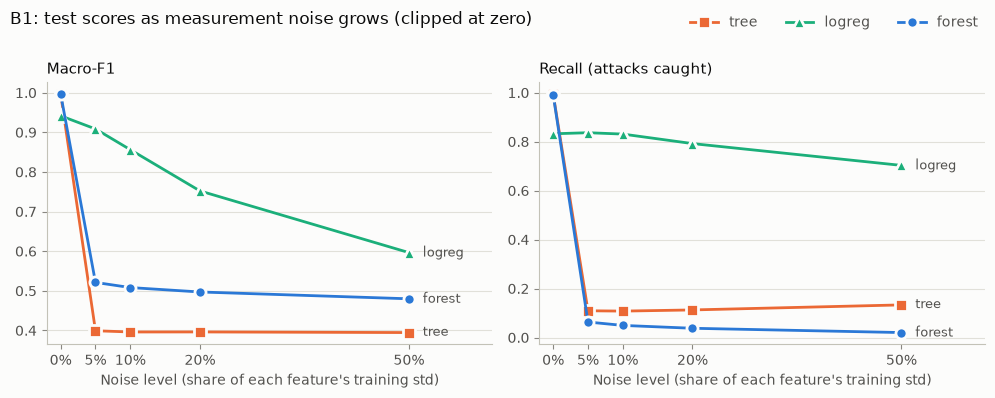

In [9]:
# STEP B1
# Figure: macro-F1 and recall against the noise level, one line per model (with clipping).
# Fixed colour per model (the same in every figure of this lab), plus a marker shape and a direct
# label, so a model is never identified by colour alone.
MODEL_COLORS = {"forest": "#2a78d6", "tree": "#eb6834", "logreg": "#1baf7a"}
MODEL_MARKERS = {"forest": "o", "tree": "s", "logreg": "^"}
INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"


def style_axes(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(axis="y", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
    ax.tick_params(colors=MUTED, labelcolor=INK_2)


def label_line_ends(ax, ends, min_gap):
    """Write each model's name at the right end of its line, nudged apart so labels never overlap."""
    placed = []
    for name, y in sorted(ends.items(), key=lambda kv: kv[1]):
        y_text = max(y, placed[-1] + min_gap) if placed else y
        placed.append(y_text)
        ax.annotate(name, xy=(NOISE_LEVELS[-1], y), xytext=(10, 0), textcoords="offset points",
                    va="center", color=INK_2, fontsize=9)
        if abs(y_text - y) > 1e-9:   # move the text, keep the anchor on the line
            ax.texts[-1].set_position((NOISE_LEVELS[-1], y_text))
            ax.texts[-1].xyann = (10, 0)


fig, axes = plt.subplots(1, 2, figsize=(10, 4), facecolor=SURFACE)
for ax, metric, title in zip(axes, ("macro_f1", "recall"), ("Macro-F1", "Recall (attacks caught)")):
    style_axes(ax)
    ends = {}
    for name in MODELS:
        part = noise[noise["model"] == name]
        ax.plot(part["level"], part[metric], color=MODEL_COLORS[name], linewidth=2,
                marker=MODEL_MARKERS[name], markersize=8, markeredgecolor=SURFACE,
                markeredgewidth=2, label=name)
        ends[name] = part[metric].iloc[-1]
    lo, hi = ax.get_ylim()
    label_line_ends(ax, ends, min_gap=(hi - lo) * 0.06)
    ax.set_xlim(-0.02, NOISE_LEVELS[-1] + 0.12)
    ax.set_xticks(NOISE_LEVELS)
    ax.set_xticklabels([f"{l:.0%}" for l in NOISE_LEVELS])
    ax.set_xlabel("Noise level (share of each feature's training std)", color=INK_2)
    ax.set_title(title, color=INK, loc="left", fontsize=11)
fig.suptitle("B1: test scores as measurement noise grows (clipped at zero)", color=INK, x=0.01,
             ha="left", fontsize=12)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=3, frameon=False, labelcolor=INK_2,
           bbox_to_anchor=(0.99, 1.0))
fig.tight_layout(rect=(0, 0, 1, 0.97))
fig.savefig("results/figures/B1_noise_curves.png", dpi=150, facecolor=SURFACE)
plt.show()

<!-- STEP B1 -->
**Why do the trees collapse at only 5%?** The lab expects the forest to lose very little, but on our
data both tree models lose almost all their recall. The next cell shows why. The noise width is a
share of each column's *standard deviation*, and A1 found extreme outliers (recording bugs, a few
flows lasting hours). Those outliers blow up the standard deviation, so for some columns "5% of the
std" is hundreds or thousands of times the spread of an ordinary flow. The cell measures three things
on 3,000 test attacks:

1. how much bigger the std is than a robust spread (the interquartile range / 1.349, which ignores
   outliers);
2. forest and tree recall when **all** continuous columns get std-scaled noise at much smaller levels;
3. the same experiment with noise scaled by the robust spread instead of the std (for comparison
   only; the lab's method stays the main result).

In [10]:
# STEP B1
attack_rows = np.random.default_rng(SEED).choice(np.flatnonzero(y_test.to_numpy() == 1), 3000,
                                                 replace=False)
X_att = X_test.iloc[attack_rows]
robust_sd = (X_train[CONT_COLS].quantile(0.75) - X_train[CONT_COLS].quantile(0.25)) / 1.349

scale = pd.DataFrame({"train_std": TRAIN_STD[CONT_COLS], "robust_sd": robust_sd,
                      "median": TRAIN_MEDIAN[CONT_COLS]})
scale["std_over_robust"] = scale["train_std"] / scale["robust_sd"].replace(0, np.nan)
print("Columns whose std is most inflated by outliers:")
print(scale.sort_values("std_over_robust", ascending=False).head(6)
      .to_string(float_format=lambda v: f"{v:,.1f}"))

print("\nRecall on 3,000 test attacks, std-scaled noise on all continuous columns:")
for level in (0.0005, 0.001, 0.005, 0.01, 0.05):
    Xn = add_noise(X_att, X_train, level)
    print(f"  level {level:<7} forest {rf.predict(Xn).mean():.3f}   tree {tree.predict(Xn).mean():.3f}"
          f"   logreg {logreg.predict(Xn).mean():.3f}")

print("\nSame, but noise scaled by the robust spread instead of the std (comparison only):")
gauss = np.random.default_rng(SEED).standard_normal((len(X_att), len(CONT_COLS)))
for level in (0.05, 0.10, 0.20, 0.50):
    Xn = X_att.copy()
    vals = Xn[CONT_COLS].to_numpy(dtype=float) + gauss * level * robust_sd.to_numpy()
    nonneg = np.isin(CONT_COLS, NONNEG_COLS)
    vals[:, nonneg] = np.maximum(vals[:, nonneg], 0.0)
    Xn[CONT_COLS] = vals
    print(f"  level {level:<5} forest {rf.predict(Xn).mean():.3f}   tree {tree.predict(Xn).mean():.3f}"
          f"   logreg {logreg.predict(Xn).mean():.3f}")

Columns whose std is most inflated by outliers:
               train_std  robust_sd  median  std_over_robust
Active Max   1,117,723.2        0.7     0.0      1,507,808.6
Active Mean    694,542.0        0.7     0.0        936,937.2
Active Min     611,394.1        0.7     0.0        824,770.6
Bwd IAT Min  9,281,328.6       35.6     3.0        260,844.0
Fwd IAT Min  9,547,685.8       49.7     3.0        192,236.2
Flow IAT Min 3,168,819.1       56.3     4.0         56,246.5

Recall on 3,000 test attacks, std-scaled noise on all continuous columns:


  level 0.0005  forest 0.859   tree 0.668   logreg 0.841


  level 0.001   forest 0.794   tree 0.500   logreg 0.840


  level 0.005   forest 0.375   tree 0.203   logreg 0.835


  level 0.01    forest 0.206   tree 0.154   logreg 0.835


  level 0.05    forest 0.072   tree 0.119   logreg 0.837

Same, but noise scaled by the robust spread instead of the std (comparison only):


  level 0.05  forest 0.768   tree 0.475   logreg 0.822


  level 0.1   forest 0.750   tree 0.296   logreg 0.814
  level 0.2   forest 0.740   tree 0.197   logreg 0.805


  level 0.5   forest 0.716   tree 0.142   logreg 0.763


<!-- STEP B1 -->
**What we found (B1).**

| Noise level | 0% | 5% | 10% | 20% | 50% |
|---|---|---|---|---|---|
| forest macro-F1 / recall | 0.997 / 0.992 | 0.521 / 0.063 | 0.508 / 0.049 | 0.497 / 0.038 | 0.480 / 0.020 |
| tree macro-F1 / recall | 0.997 / 0.995 | 0.399 / 0.109 | 0.396 / 0.108 | 0.396 / 0.113 | 0.395 / 0.133 |
| logreg macro-F1 / recall | 0.942 / 0.832 | 0.909 / 0.836 | 0.856 / 0.831 | 0.752 / 0.792 | 0.596 / 0.703 |

Unlike the lab's expectation, the forest does **not** survive 5% noise on our data: it loses 93% of its
recall and calls nearly every flow benign (its FAR drops to 0). The single tree loses as much recall
*and* starts raising false alarms on a third of the benign flows (FAR 0.34), which is close to
guessing. Logistic regression, the weakest model on clean data, is by far the most robust: at 5% it
keeps 0.84 recall.

The diagnostic cell explains why. The standard deviation of several columns is inflated by outliers by
a factor of 50,000 to 1,500,000 (`Active …`, `Fwd/Bwd/Flow IAT Min`). For those columns even 0.05% of
the std is a huge change for an ordinary flow, and the trees split on exactly those small timing values
(a flood attack sends packets microseconds apart). Even at a level of 0.0005 the forest's recall falls
to 0.86. Noise on **one** column at a time barely hurts (we checked: each costs less than 0.01 recall),
because its twins still carry the signal; noise on all columns at once removes every twin together.
Logistic regression is protected by its scaler: it reads each feature in units of the training std,
so to it the noise really is only 5%. With noise sized by a robust spread instead of the std, the
forest keeps about 0.75 recall at every level and the tree falls more slowly. So the damage is not
just uneven, as the lab's hint warns: it is dominated by the heavy tails.

**Check yourself: why does a single tree fall apart faster than a forest of 300 trees?** At small
noise levels it does: at level 0.001 the tree keeps 0.50 recall and the forest 0.79, at 0.005 the tree
0.20 and the forest 0.38. One tree has one path per flow, so a single threshold crossed by noise flips
its answer. The forest averages 300 trees built on different bootstrap samples and feature subsets, so
a flipped tree is outvoted until noise crosses the thresholds of most trees at once. At 5% std-scaled
noise that happens for both, because all trees rely on the same timing features. The tree's scores
are still worse at every level above 0 (macro-F1 0.40 vs 0.52 at 5%). Its slightly higher recall is
not detection: it comes with a FAR of 0.34.

**Check yourself: did clipping at zero change the results, and is a negative packet count a fair test?**
See X2 below: clipping changed **nothing** for the tree and the forest (identical to 4 decimals) and
improved logistic regression's macro-F1 by up to 0.024. For the trees, every split threshold on a
never-negative column lies at or above zero, so −5 and 0 land on the same side of every split. A
negative packet count is not a fair test: it describes a flow that cannot exist, so a model that fails
on it has not shown a weakness that matters in production. We therefore report the clipped run.

<!-- STEP X2 -->
### Extra X2: does clipping at zero change the results?

The same experiment without clipping, next to the clipped run.

In [11]:
# STEP X2
clip_cmp = noise_all.pivot_table(index=["model", "level"], columns="clip",
                                 values=["macro_f1", "recall"])
clip_cmp.columns = [f"{m}_{'clipped' if c else 'not_clipped'}" for m, c in clip_cmp.columns]
clip_cmp["macro_f1_diff"] = clip_cmp["macro_f1_clipped"] - clip_cmp["macro_f1_not_clipped"]
clip_cmp["recall_diff"] = clip_cmp["recall_clipped"] - clip_cmp["recall_not_clipped"]
clip_cmp.to_csv("results/tables/X2_clip_vs_noclip.csv", float_format="%.4f")
clip_cmp.round(4)

macro_f1_not_clipped  macro_f1_clipped  recall_not_clipped  \
model  level                                                               
forest 0.00                 0.9968            0.9968              0.9923   
       0.05                 0.5212            0.5212              0.0633   
       0.10                 0.5082            0.5082              0.0494   
       0.20                 0.4970            0.4970              0.0377   
       0.50                 0.4798            0.4798              0.0202   
logreg 0.00                 0.9416            0.9416              0.8320   
       0.05                 0.9001            0.9085              0.8405   
       0.10                 0.8352            0.8561              0.8338   
       0.20                 0.7280            0.7521              0.7935   
       0.50                 0.5891            0.5964              0.7092   
tree   0.00                 0.9970            0.9970              0.9950   
       0.05                 0.3992            0.3992              0.1092   
       0.10                 0.3961            0.3961              0.1079   
       0.20                 0.3962            0.3962              0.1126   
       0.50                 0.3946            0.3946              0.1332   

              recall_clipped  macro_f1_diff  recall_diff  
model  level                                              
forest 0.00           0.9923         0.0000       0.0000  
       0.05           0.0633         0.0000       0.0000  
       0.10           0.0494         0.0000       0.0000  
       0.20           0.0377         0.0000       0.0000  
       0.50           0.0202         0.0000       0.0000  
logreg 0.00           0.8320         0.0000       0.0000  
       0.05           0.8364         0.0084      -0.0041  
       0.10           0.8308         0.0210      -0.0030  
       0.20           0.7920         0.0241      -0.0015  
       0.50           0.7029         0.0073      -0.0062  
tree   0.00           0.9950         0.0000       0.0000  
       0.05           0.1092         0.0000       0.0000  
       0.10           0.1079         0.0000       0.0000  
       0.20           0.1126         0.0000       0.0000  
       0.50           0.1332         0.0000       0.0000

<!-- STEP X2 -->
Clipping makes no difference for the two tree models and a small one for logistic regression (macro-F1
+0.007 to +0.024 at 5–50% noise), whose linear score does react to an impossible negative value.

<!-- STEP B2 -->
### Step B2: Lose some features

A collector under load drops fields. `add_missing` simulates that: in every row it picks a random 10%
of the features (7 of the 68, a different 7 in each row) and replaces them with the **training**
median, which is the ordinary value a model should assume when it is told nothing.

In [12]:
# STEP B2
def add_missing(X, frac, seed=SEED):
    """Copy of X where round(frac * n_features) random features per row are set to TRAIN_MEDIAN."""
    out = X.to_numpy(dtype=float, copy=True)
    k = int(round(frac * X.shape[1]))
    if k > 0:
        rng = np.random.default_rng(seed)
        # k random columns per row: the positions of the k smallest of a row of random numbers.
        cols = np.argpartition(rng.random(out.shape), k - 1, axis=1)[:, :k]
        out[np.arange(len(out))[:, None], cols] = TRAIN_MEDIAN.to_numpy()[cols]
    return pd.DataFrame(out, index=X.index, columns=X.columns)


_check = add_missing(X_test.iloc[:1000], 0.10)
_changed = (_check.to_numpy() != X_test.iloc[:1000].to_numpy())
assert _changed.sum(axis=1).max() <= 7          # at most 7 values per row change (fewer if already = median)
print(f"Per row, {int(round(0.10 * len(FEATURES)))} of {len(FEATURES)} features are replaced "
      f"by the training median ({7 / len(FEATURES):.1%})")

Per row, 7 of 68 features are replaced by the training median (10.3%)


In [13]:
# STEP B2
X_missing = add_missing(X_test, 0.10)
missing = pd.DataFrame({name: report(model, X_missing, y_test) for name, model in MODELS.items()}).T
missing.index.name = "model"

clean_scores = baseline.loc[list(MODELS)]               # A2: clean test scores
noise5 = noise[noise["level"] == 0.05].set_index("model")[missing.columns]
compare = pd.concat({"clean": clean_scores, "10% missing": missing, "5% noise": noise5}, axis=1)
compare = compare.swaplevel(axis=1)[["macro_f1", "recall", "pr_auc", "far"]]
missing.to_csv("results/tables/B2_missing.csv", float_format="%.4f")
compare.round(4)

macro_f1                       recall                       pr_auc  \
          clean 10% missing 5% noise   clean 10% missing 5% noise   clean   
model                                                                       
tree     0.9970      0.8763   0.3992  0.9950      0.7462   0.1092  0.9907   
logreg   0.9416      0.7776   0.9085  0.8320      0.6092   0.8364  0.9693   
forest   0.9968      0.9900   0.5212  0.9923      0.9681   0.0633  0.9998   

                                far                       
       10% missing 5% noise   clean 10% missing 5% noise  
model                                                     
tree        0.6612   0.1401  0.0009      0.0262   0.3398  
logreg      0.6520   0.9377  0.0032      0.0626   0.0257  
forest      0.9992   0.8317  0.0006      0.0003   0.0000

<!-- STEP B2 -->
**What we found (B2).** With 10% of each flow's values replaced by the training median, the forest
barely notices (macro-F1 0.997 → 0.990, recall 0.992 → 0.968). The tree loses a quarter of its recall
(0.995 → 0.746) and logistic regression the most (0.832 → 0.609, with its FAR rising from 0.003 to
0.063).

**Check yourself: which does more damage, noise or missing values?** It depends on the model, which is
the main lesson of Part B. For the tree models, noise is far worse: 5% noise leaves the forest 0.06
recall, 10% missing values leave it 0.97. For logistic regression it is the other way round: 5% noise
leaves 0.84 recall, 10% missing values 0.61. A median is an ordinary value for a tree, which simply
follows the "typical flow" branch for that feature while the other 61 features still decide. For a
linear model, replacing an attack's extreme value with the median removes a large part of the evidence
in one jump, and seven such jumps per flow add up. No model is safest against both kinds of damage:
the forest is safest when fields go missing, logistic regression when measurements are noisy.

<!-- STEP X1 -->
### Extra X1: a whole group of fields fails at once

In a real collector, fields do not go missing one at a time: a whole group fails together. Here we
replace **every backward-direction feature** (17 features, everything the responder sends) or **every
idle timer** (4 features) with the training median, in every test flow. For a fair comparison we also
run random missingness of the same size: 25% random (17 features per row) and 6% random (4 per row).

In [14]:
# STEP X1
BWD_COLS = [c for c in FEATURES if "Bwd" in c or "backward" in c.lower()]
IDLE_COLS = [c for c in FEATURES if c.startswith("Idle")]


def drop_group(X, cols):
    """Copy of X with the whole group of columns set to the training median."""
    out = X.copy()
    out[cols] = np.broadcast_to(TRAIN_MEDIAN[cols].to_numpy(), (len(X), len(cols)))
    return out


scenarios = {
    "random 10% (7 per row)": add_missing(X_test, 0.10),
    f"all backward ({len(BWD_COLS)})": drop_group(X_test, BWD_COLS),
    f"random {len(BWD_COLS)} per row": add_missing(X_test, len(BWD_COLS) / len(FEATURES)),
    f"all idle timers ({len(IDLE_COLS)})": drop_group(X_test, IDLE_COLS),
    f"random {len(IDLE_COLS)} per row": add_missing(X_test, len(IDLE_COLS) / len(FEATURES)),
}
group_rows = [{"scenario": s, "model": name, **report(model, Xs, y_test)}
              for s, Xs in scenarios.items() for name, model in MODELS.items()]
group_missing = pd.DataFrame(group_rows)
group_missing.to_csv("results/tables/X1_group_missing.csv", index=False, float_format="%.4f")
print("Macro-F1")
print(group_missing.pivot(index="scenario", columns="model", values="macro_f1")
      .loc[list(scenarios)].round(4).to_string())
print("\nRecall")
print(group_missing.pivot(index="scenario", columns="model", values="recall")
      .loc[list(scenarios)].round(4).to_string())

Macro-F1
model                   forest  logreg    tree
scenario                                      
random 10% (7 per row)  0.9900  0.7776  0.8763
all backward (17)       0.4603  0.6370  0.6165
random 17 per row       0.8921  0.7098  0.7306
all idle timers (4)     0.9944  0.9076  0.9949
random 4 per row        0.9957  0.8268  0.9270

Recall
model                   forest  logreg    tree
scenario                                      
random 10% (7 per row)  0.9681  0.6092  0.7462
all backward (17)       0.0010  0.2428  0.2082
random 17 per row       0.6829  0.5467  0.4653
all idle timers (4)     0.9843  0.7297  0.9879
random 4 per row        0.9886  0.6685  0.8509


<!-- STEP X1 -->
**Check yourself: would a whole group failing together be worse?** Yes, much worse, if it is a group the
model relies on. Losing **all 17 backward features** at once leaves the forest with a recall of
**0.001**: it misses practically every attack. The same number of values missing *at random* (17 per
row) still leaves it 0.68. The reason is the twins again: random missingness almost always leaves a twin
of each lost feature behind, but a group failure takes out the feature *and* its twins (T4 found that
9 of the 17 backward features sit in twin groups 2, 6 and 11). Losing all four idle timers, on the other
hand, costs almost nothing (forest macro-F1 0.994), because the forest hardly uses them. So our
random-10% simulation is optimistic: a realistic collector failure can be far more damaging, depending
on which group fails.